In [10]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle

from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL

import yaml
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")
source_rcw86 = catalog_4fgl["4FGL J1443.0-6227e"]

In [26]:
source_rcw86

/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/gammapy/catalog/fermi.py:218: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_BAY", d["ASSOC_PROB_BAY"])
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/gammapy/catalog/fermi.py:219: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_LR", d["ASSOC_PROB_LR"])


In [2]:
# Create a GTAnalysis object from the configuration file.
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/fermi_config_rcw86_2008_2025_7.5deg_1GeV_PSF1-3.yaml', logging={'verbosity': 3})

2025-05-21 11:52:09 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [3]:
gta.setup()

2025-05-21 11:52:10 INFO    GTAnalysis.setup(): Running setup.
2025-05-21 11:52:10 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-05-21 11:52:10 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-05-21 11:52:10 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-05-21 11:52:10 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 54682.655283 from DATE-OBS.
Set MJD-END to 60808.154921 from DATE-END'. [astropy.wcs.wcs]
2025-05-21 11:52:10 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2025-05-21 11:52:10 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2025-05-21 11:52:10 INFO    GTBinnedAnalysis.setup(): Running setup for component 01
2025-05-21 11:52:10 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-05-21 11:52:10 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-0

In [4]:
gta.free_sources(free=False)
gta.free_sources(distance=[3.0],free=True)
gta.print_model()

2025-05-21 11:52:47 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1443.0-6227e    : ['Prefactor', 'Index']
2025-05-21 11:52:47 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1433.8-6357     : ['norm', 'alpha', 'beta']
2025-05-21 11:52:47 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.8-6122     : ['Prefactor', 'Index']
2025-05-21 11:52:47 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1422.5-6137     : ['Prefactor', 'IndexS', 'ExpfactorS']
2025-05-21 11:52:47 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1427.8-6051     : ['norm', 'alpha', 'beta']
2025-05-21 11:52:47 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1424.2-6111c    : ['norm', 'alpha', 'beta']
2025-05-21 11:52:47 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1435.8-6018     : ['norm', 'alpha', 'beta']
2025-05-21 11:52:47 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1501.0-6310e    : ['no

In [5]:
gta.optimize()
gta.fit()

2025-05-21 11:53:01 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1418.7-6057', 'isodiff', '4FGL J1413.5-6205', '4FGL J1409.1-6121e']
Drm_Cache::update Measured counts < 0 4FGL J1413.5-6205 21 -3.04449e-11 2.81574e-11
0.684173 0.560536 0.431708 0.314127 0.214228 0.137126 0.0816477 0.0457027 0.0233874 0.0108911 0.0046317 0.00176868 0.000600571 0.000180608 4.73089e-05 1.07085e-05 2.07474e-06 3.38392e-07 4.56237e-08 4.9843e-09 4.27117e-10 2.81574e-11 


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 5691130.386
Fitting shape 4FGL J1418.7-6057 TS:  17231.731
Fitting shape 4FGL J1413.5-6205 TS:  17102.867
Fitting shape 4FGL J1409.1-6121e TS:  10289.015
Fitting shape 4FGL J1459.5-6053 TS:   9689.856
Fitting shape 4FGL J1429.9-5911 TS:   8498.067
Fitting shape 4FGL J1422.5-6137 TS:   4551.189
Fitting shape 4FGL J1420.0-6048 TS:   2550.223
Fitting shape 4FGL J1501.0-6310e TS:    880.106
Fitting shape 4FGL J1427.8-6051 TS:    686.754
Fitting shape 4FGL J1442.2-6005 TS:    419.630
Fitting shape 4FGL J1420.3-6046e TS:    405.453
Fitting shape 4FGL J1444.9-5939 TS:    367.089
Fitting shape 4FGL J1507.9-6228e TS:    341.729
Fitting shape 4FGL J1415.4-6458 TS:    251.691
Fitting shape 4FGL J1450.2-5937c TS:    234.413
Fitting shape 4FGL J1435.8-6018 TS:    231.053
Fitting shape 4FGL J1443.0-6227e TS:    205.091
Fitting shape 4FGL J1456.4-5923c TS:    188.737
Fitting shape 4FGL J1428.0-6026c TS:    179.446
Fitting shape 4FGL J1441.6-5951c TS:    157.229
Fitting shape

2025-05-21 11:54:42 INFO    GTAnalysis.optimize(): Finished
2025-05-21 11:54:42 INFO    GTAnalysis.optimize(): LogLike: -968653.064624 Delta-LogLike: 14564.718381
2025-05-21 11:54:42 INFO    GTAnalysis.optimize(): Execution time: 101.35 s
2025-05-21 11:54:42 INFO    GTAnalysis.fit(): Starting fit.
2025-05-21 11:56:23 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   2 Status: 102
2025-05-21 11:56:23 INFO    GTAnalysis.fit(): LogLike:  -968601.350 DeltaLogLike:       51.715 


{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 51.715039612259716,
 'edm': 0.00011862740599404589,
 'loglike': -968601.3495840942,
 'covariance': array([[ 1.36143287e-03, -2.10417941e-04,  2.05547780e-04, ...,
         -3.66989515e-08,  4.53051741e-08, -1.98479404e-12],
        [-2.10417941e-04,  7.73606564e-04,  1.72039333e-04, ...,
         -1.32606170e-08, -4.57282557e-09, -7.39158592e-13],
        [ 2.05547780e-04,  1.72039333e-04,  3.42779890e-03, ...,
          3.66642032e-08, -3.60831897e-08,  2.98875984e-12],
        ...,
        [-3.66989515e-08, -1.32606170e-08,  3.66642032e-08, ...,
          8.35187415e-08,  6.02386408e-09, -1.73461067e-12],
        [ 4.53051741e-08, -4.57282557e-09, -3.60831897e-08, ...,
          6.02386408e-09,  1.36706091e-07,  2.22054314e-12],
        [-1.98479404e-12, -7.39158592e-13,  2.98875984e-12, ...,
         -1.73461067e-12,  2.22054314e-12,  1.55410533e-13]]),
 'correlation': array([[ 1.00000000e+00, -2.05033384e-01,

In [8]:
gta.print_model()

2025-05-21 15:20:53 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1443.0-6227e     0.353   1.673  1.05e-05   1.76    208.01       481.8    *
4FGL J1433.8-6357      1.515   3.146  1.69e-06   3.06    126.57       419.9    *
4FGL J1456.8-6122      2.296   1.265  1.01e-06   2.60     22.10       190.5    *
4FGL J1422.5-6137      2.330   1.245  2.83e-05   2.31   4310.22      4892.3    *
4FGL J1427.8-6051      2.334   3.012  1.15e-05   2.85    669.55      2481.3    *
4FGL J1424.2-6111c     2.395   0.500  3.11e-06   3.72     70.24       864.5    *
4FGL J1435.8-6018      2.396   3.033  4.76e-06   5.22    270.65      1518.3    *
4FGL J1501.0-6310e     2.397   7.552  3.25e-05   2.62   1010.11      5018.2    *
4FGL J1449.4-6026      2.452   4.561  2.93e-06   3.70    117.24       819.5    *
4FGL J1430.9-6024c     2.500   2.455  3.44e-06   3.08 

2025-05-21 15:21:04 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2008_2025_7.5deg_1GeV_PSF1-3/initial_00.xml...
2025-05-21 15:21:04 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2008_2025_7.5deg_1GeV_PSF1-3/initial_01.xml...
2025-05-21 15:21:04 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2008_2025_7.5deg_1GeV_PSF1-3/initial_02.xml...
2025-05-21 15:21:04 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2008_2025_7.5deg_1GeV_PSF1-3/initial.fits...
2025-05-21 15:21:07 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-05-21 15:21:07 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 01.
2025-05-21 15:21:07 INFO    G

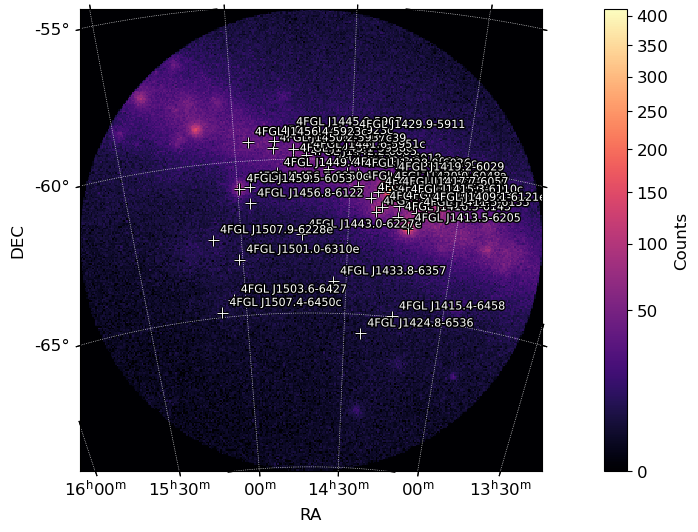

In [9]:
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

In [11]:
plt.clf()
tsmap_excluded = gta.tsmap(
    prefix='TSmap_start',
    make_plots=True,
    write_fits=True,
    write_npy=True, 
    exclude = gta.roi.sources[0].name
)

2025-05-21 15:21:57 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-21 15:22:02 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-21 15:23:53 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-21 15:23:56 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_2008_2025_7.5deg_1GeV_PSF1-3/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-05-21 15:23:56 INFO    GTAnalysis.tsmap(): Execution time: 118.79 s


<Figure size 640x480 with 0 Axes>

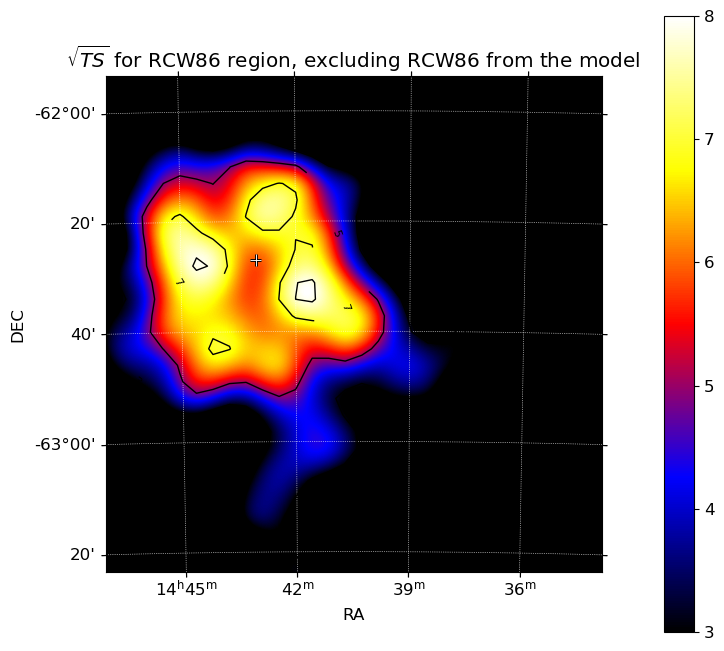

In [37]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               #graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=1000.0)  # optional threshold for labeling
plt.figure(figsize=(8, 8))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=10,vmin=3,vmax=8, levels=[3,5,7,8])


snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

# p.draw_circle(0.11,  # radius in degrees
#               skydir=snr_g_043,
#               edgecolor='cyan',
#               linewidth=2.0,
#               linestyle='--')
plt.title("$\sqrt{TS}$ for RCW86 region, excluding RCW86 from the model",)
plt.show()

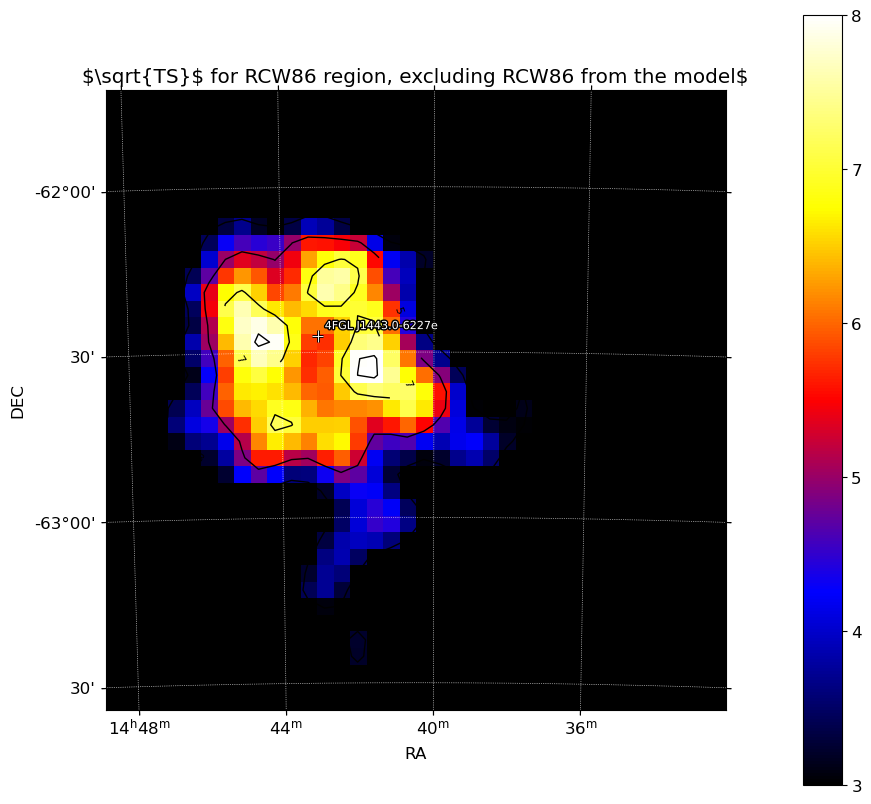

In [28]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               #graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=100.0)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='none', zoom=8,vmin=3,vmax=8, levels=[3,5,7,8])


snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

# p.draw_circle(0.11,  # radius in degrees
#               skydir=snr_g_043,
#               edgecolor='cyan',
#               linewidth=2.0,
#               linestyle='--')
plt.title("$\sqrt{TS}$ for RCW86 region, excluding RCW86 from the model$",)
plt.show()

In [49]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-04-16 11:52:08 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-16 11:52:12 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-16 13:12:06 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-16 13:12:08 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-04-16 13:12:08 INFO    GTAnalysis.tsmap(): Execution time: 4800.70 s


<Figure size 640x480 with 0 Axes>

In [55]:
gta.print_roi()

2025-04-16 13:17:42 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1443.0-6227e  SpatialMap     PowerLaw          0.353    164.61       479.6
4FGL J1433.8-6357   PointSource    LogParabola       1.515     35.85       237.5
4FGL J1456.8-6122   PointSource    PowerLaw          2.296     11.07       618.1
4FGL J1422.5-6137   PointSource    PLSuperExpCuto    2.330   3745.40      8931.4
4FGL J1427.8-6051   PointSource    LogParabola       2.334    477.22     10514.5
4FGL J1424.2-6111c  PointSource    LogParabola       2.395     60.02      2858.9
4FGL J1435.8-6018   PointSource    LogParabola       2.396    115.35      4141.8
4FGL J1501.0-6310e  RadialGaussian LogParabola       2.397    155.70      5492.3
4FGL J1449.4-6026   PointSource    LogParabola       2.453     25.74       938.7
4FGL J1430.9-6024c  PointSource    LogParabola       2.5

<Figure size 640x480 with 0 Axes>

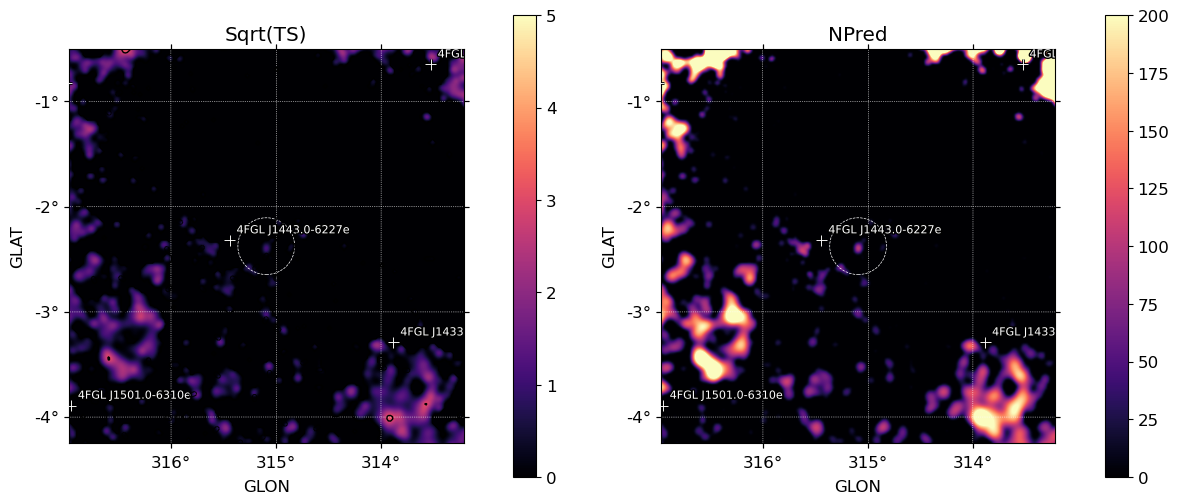

In [54]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

In [57]:
plt.clf()
tsmap_excluded = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True, exclude = gta.roi.sources[0].name)

2025-04-16 13:57:00 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-16 13:57:05 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/fermipy/tsmap.py:933: RuntimeWarning: invalid value encountered in sqrt
  sqrt_ts_map = WcsNDMap(map_geom, ts_values**0.5)
2025-04-16 14:53:32 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-16 14:53:34 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-04-16 14:53:34 INFO    GTAnalysis.tsmap(): Execution time: 3393.86 s


<Figure size 640x480 with 0 Axes>

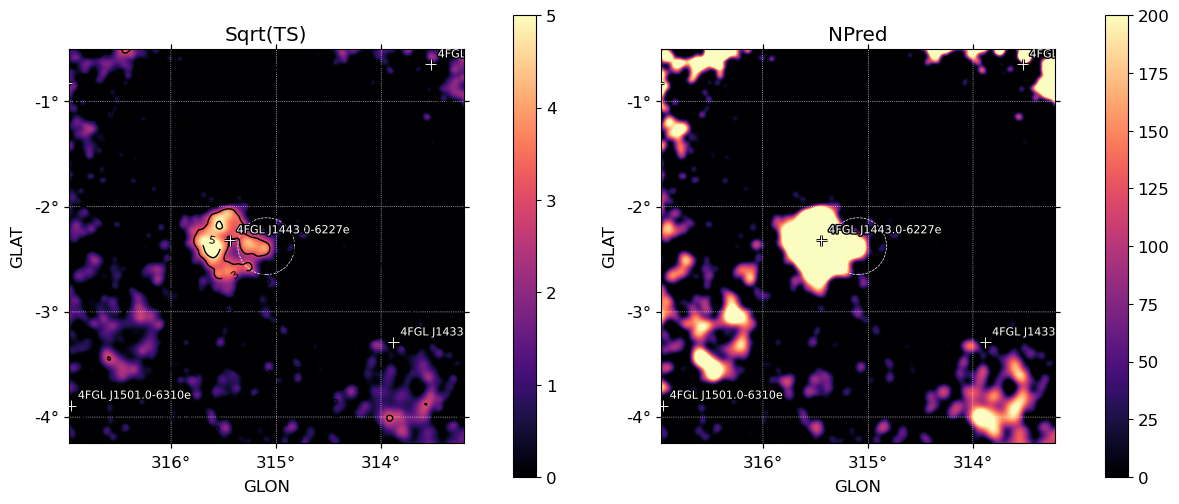

In [58]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_excluded['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_excluded['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

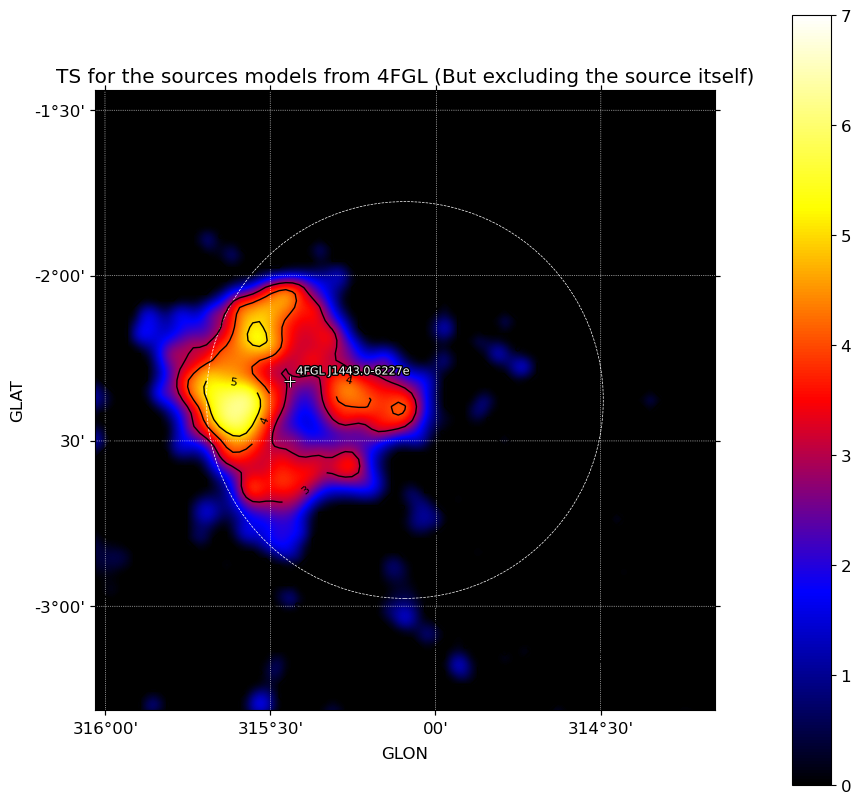

In [65]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=100.0)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=4,vmin=0,vmax=7, levels=[0,3,4,5])
from astropy.coordinates import SkyCoord

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')
plt.title("TS for the sources models from 4FGL (But excluding the source itself)")
plt.show()

In [63]:
print(tsmap_excluded['sqrt_ts'].geom.frame)

galactic


In [24]:
for src_info in gta.roi.sources:
    print(src_info)

Name           : 4FGL J1443.0-6227e
Associations   : ['4FGL J1443.0-6227e', 'RCW 86']
RA/DEC         :    220.760/   -62.450
GLON/GLAT      :    315.442/    -2.320
TS             : nan
Npred          : 714.17
Flux           : 1.686e-09 +/-      nan
EnergyFlux     : 1.369e-05 +/-      nan
SpatialModel   : SpatialMap
SpectrumType   : PowerLaw
Spectral Parameters
b'Prefactor'   :  1.695e-15 +/-        nan
b'Index'       :     -1.471 +/-        nan
b'Scale'       :  3.168e+04 +/-        nan
Name           : 4FGL J1433.8-6357
Associations   : ['4FGL J1433.8-6357']
RA/DEC         :    218.459/   -63.963
GLON/GLAT      :    313.883/    -3.290
TS             : nan
Npred          : 658.91
Flux           : 1.337e-09 +/-      nan
EnergyFlux     :  1.48e-06 +/-      nan
SpatialModel   : PointSource
SpectrumType   : LogParabola
Spectral Parameters
b'norm'        :   1.79e-13 +/-        nan
b'alpha'       :      2.109 +/-        nan
b'beta'        :     0.5626 +/-        nan
b'Eb'          :       1